# Nadaraya-Watson

This section presents a simple yet complete demonstration of the attention mechanism through the kernel regression modell proposed in 1964

In [1]:
# 这里torch和d2l的torch有什么区别?
import torch  # torch：是官方核心库（PyTorch 本体）
from torch import nn
from d2l import torch as d2l  # d2l.torch：是李沐老师写的辅助工具包（为了教学方便封装的函数）

## Generate the dataset

For simplicity,consider the following regression problem:given a dataset $\left \{(x_1,y_1),\cdot\cdot\cdot,(x_n,y_n)\right \}$ of "input-output"pairs,how to learn $f$ to predict the output $\hat{y}=f(x)$ for any new input $x$?

Generate an artificial dataset based on the following nonlinear function:
$$
y_i=2\sin (x_i)+x^{0.8}_i+\epsilon
$$

where,$\epsilon$ is the added noise term,following anormal distribution with a mean of 0 and a standard deviation of 0.5.Here,50 training samples and 50 test samples are generated.To better visualize the attention pattens later,the samples need to be sorted.

In [2]:
n_train = 50  # 训练样本数
# torch.rand(n_train) * 5 :生成一个长度为 n_train(50) 的一维张量（数组）且里面的数值都是 0 ~ 1 之间的随机小数.并把上面 0~1 的随机数 放大 5 倍,为0 ~ 5
# torch.sort :对上面生成的 0~5 随机张量进行从小到大排序
# x_train, _:逗号 = 同时接收多个返回值,torch.sort() 这个函数，一次会返回两个东西：1.排序好的数值 2.排序对应的索引.
# _ 它不是特殊语法，就是一个普通变量名，但程序员约定俗成：用 _ 表示 用不到、不关心、可以丢弃 的变量
# 总结：torch.sort函数返回1.排序好的数值 2.排序对应的索引.分别用 x_train和 _接收
x_train, _ = torch.sort(torch.rand(n_train) * 5)  # 排序后的训练样本
def f(x):
    return 2 * torch.sin(x) + x**0.8
# torch.normal(0.0, 0.5, (n_train,)):这是生成高斯随机噪声（就是给数据加点干扰），三个参数意思：
# 0.0：噪声的均值（整体不偏高不偏低）
# 0.5：噪声的标准差（越大噪声越强，数据越乱）
# (n_train,)：生成和训练样本一样多的噪声
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
# 生成一串从 0 开始，到 5 结束，每隔 0.1 取一个数的连续有序序列:torch.arange(起点, 终点, 步长)
# PyTorch 里专门生成等差数列的函数，和 Python 的 range 几乎一样。
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

The function below will plot all the training samples (represented by circles),the true data-generating function $f$ without the noise term (labeled 'Truth'),and the learned prediction function (labeled 'Pred').

In [3]:
def plot_kernel_reg(y_hat):
    # x_test横轴数据;[y_truth, y_hat]纵轴数据;legend图例;xlim,ylim横轴范围：0 ~ 5,纵轴范围：-1 ~ 5.
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'], xlim=[0, 5], ylim=[-1, 5])
    # x_train, y_train：训练用的原始数据（带噪声的散点）;'o'：画成圆点，不是线;alpha=0.5：设置透明度 50%，让图更好看.
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

## Average pooling

First,let's solve the regression problem using the simplest estimator.Compute the average of all training sample output values based on average pooling:
$$
f(x)=\frac{1}{n}\sum^{n}_{i=1}y_i
$$

As shown in the figure below,this estimator is indeed not very smart.The true function $f$(Truth) and the prediction function (Pred) differ significantly.

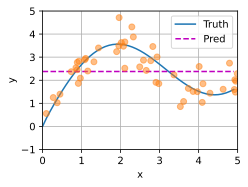

In [4]:
# 平均汇聚（Average Pooling / Average Aggregation），简单说就是：对一组数据取平均值，用这个平均值来代表整组数据
# y_train.mean():所有训练数据的标签（带噪声的点）求平均值
# torch.repeat_interleave (平均值，n_test):repeat_interleave：把一个数字重复n_test遍;结果：生成一个长度为 50 的张量，里面全是同一个平均值
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

## Nonparametric Attention Pooling

Obviously,average pooling ignores the input $x_i$.Thus,Nadaraya and Watson proposed a better idea: weighting the output $y_i$ based on the input's location:
$$
f(x)=\sum^{n}_{i=1}\frac{K(x-x_i)}{\sum^{n}_{j=1}K(x-x_j)}y_i
$$

Where,K is kernel.The estimator described by the equation above is known as Nadaraya-Watson Kernel Regression.
Inspired by this, the equation above can be rewritten from the perspective of the attention machanism framework to form a more general attention pooling formula:
$$
f(x)=\sum^{n}_{i=1}\alpha (x,x_i)y_i
$$

Where,x is query, $(x_i,y_i)$ represents the key-value pairs.
The attention pooling mechanism in the equation above is a weighted average of $y_i$
Model the relationship between the query $x$ and the keys $x_i$ as attention weights, which will be assigned to each corresponding value $y_i$.
For any query, the attention weights over all key-value pairs in the model constitute a valid probability distribution: they are non-negative and sum to 1.
To be better understand attention pooling, let's consider a Gaussion kernel,which is defined as:
$$
K(u)=\frac{1}{\sqrt{2\pi}}\exp(-\frac{u^2}{2})
$$

Substituting the Gaussian kernel into the equation above yields
$$
\begin{align*}
f(x)&=\sum^{n}_{i=1}\alpha (x,x_i)y_i\\
    &=\sum^{n}_{i=1}\frac{\exp(-\frac{1}{2}(x-x_i)^2)}{\sum^{n}_{j=1}\exp(-\frac{1}{2}(x-x_j)^2)}y_i\\
    &=\sum^{n}_{i=1}softmax(-\frac{1}{2}(x-x_i)^2)y_i
\end{align*}
$$

In the equation above, the closer a key $x_i$ is to a given query $x$, the larger the attention weight assigned to its corresponding value—meaning $y_i$ it "receives more attention."--获得了更多的注意力!
It is worth noting that the Nadaraya-Watson kernel regression is a non-parametric model. 
Therefore, the equation above represents a nonparametric attention pooling model.
Next, we will plot the prediction results based on this non-parametric attention pooling model. 
From the plotted results, we will find that the new model's prediction line is smooth and closer to the ground truth than the average pooling prediction.

非参数方法：无额外可学习参数，规则 / 函数形式固定，只依赖输入数据本身做计算，不靠训练更新权重。没有要训练的参数，逻辑写死。

参数方法：预先固定模型结构 + 可学习参数，训练中不断更新参数，拟合数据。有需要学的权重、矩阵、系数。

In [9]:
print(x_test)
print(x_train)

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000,
        1.8000, 1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000,
        2.7000, 2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000,
        3.6000, 3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000,
        4.5000, 4.6000, 4.7000, 4.8000, 4.9000])
tensor([0.0970, 0.2739, 0.3745, 0.4461, 0.7353, 0.8555, 0.8879, 0.8899, 0.9161,
        0.9305, 0.9687, 1.0811, 1.1040, 1.1580, 1.3167, 1.4336, 1.8986, 1.9540,
        1.9622, 2.0197, 2.0736, 2.1073, 2.1093, 2.2886, 2.3263, 2.4902, 2.5869,
        2.6579, 2.7731, 2.8261, 2.9069, 2.9351, 2.9800, 3.3687, 3.5312, 3.6153,
        3.7367, 3.8588, 3.9682, 4.0141, 4.0924, 4.1115, 4.2910, 4.6283, 4.7916,
        4.9162, 4.9282, 4.9438, 4.9532, 4.9907])


In [8]:
# X_repeat的形状为(n_test,n_train)
# 每一行都包含相同的测试输入（例如同样的查询）
# 可以理解为有n_test行，n_train列
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
print(X_repeat)

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
        [0.2000, 0.2000, 0.2000,  ..., 0.2000, 0.2000, 0.2000],
        ...,
        [4.7000, 4.7000, 4.7000,  ..., 4.7000, 4.7000, 4.7000],
        [4.8000, 4.8000, 4.8000,  ..., 4.8000, 4.8000, 4.8000],
        [4.9000, 4.9000, 4.9000,  ..., 4.9000, 4.9000, 4.9000]])


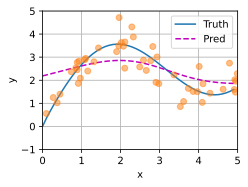

In [10]:
# x_train包含键。 attention_weights的形状为(n_test, n_train)
# 每一行都包含要在给定的每个查询的值(y_train)之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)  # 对应上面的公式
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

Now, let's observe the attention weights. 
Here, the input of the test data serves as the query, while the input of the training data acts as the key. 
Since both inputs are sorted, it can be observed that the closer a "query-key" pair is, the higher the attention weight in the attention pooling.

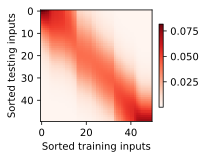

In [11]:
# d2l 的热力图函数 show_heatmaps 要求输入是 4D 张量：(批量大小 batch_size, 头数 num_heads, 行数, 列数)
# 第一个 unsqueeze(0) → 加 批量维度;第二个 unsqueeze(0) → 加 头数维度（单头注意力）
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                 xlabel='Sorted training inputs',
                 ylabel='Sorted testing inputs')

## Parametrized Attention Pooling